# Airport Network to NetworkX Graph

This notebook reads the KONECT FAA network data and creates a directed `networkx` graph.

In [5]:
from pathlib import Path
import pandas as pd
import networkx as nx

In [6]:
# Path to the edge list in the current workspace
edge_file = Path('data/download.tsv.maayan-faa/maayan-faa/out.maayan-faa')

# Read only edge rows (skip the % header line)
edges_df = pd.read_csv(
    edge_file,
    delim_whitespace=True,
    comment='%',
    header=None,
    usecols=[0, 1],
    names=['source', 'target']
)

edges_df.head()

,source,target
0,1,2
1,2,3
2,3,4
3,4,5
4,1,6


In [7]:
# The dataset is marked as asymmetric, so we build a directed graph
G = nx.from_pandas_edgelist(
    edges_df,
    source='source',
    target='target',
    create_using=nx.DiGraph()
)

print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')
print(f'Is directed: {G.is_directed()}')

Nodes: 1226
Edges: 2615
Is directed: True


In [8]:
# Optional quick check of a few edges
list(G.edges())[:10]

[(1, 2),
 (1, 6),
 (1, 20),
 (1, 10),
 (1, 46),
 (1, 14),
 (2, 3),
 (2, 14),
 (2, 18),
 (2, 23)]

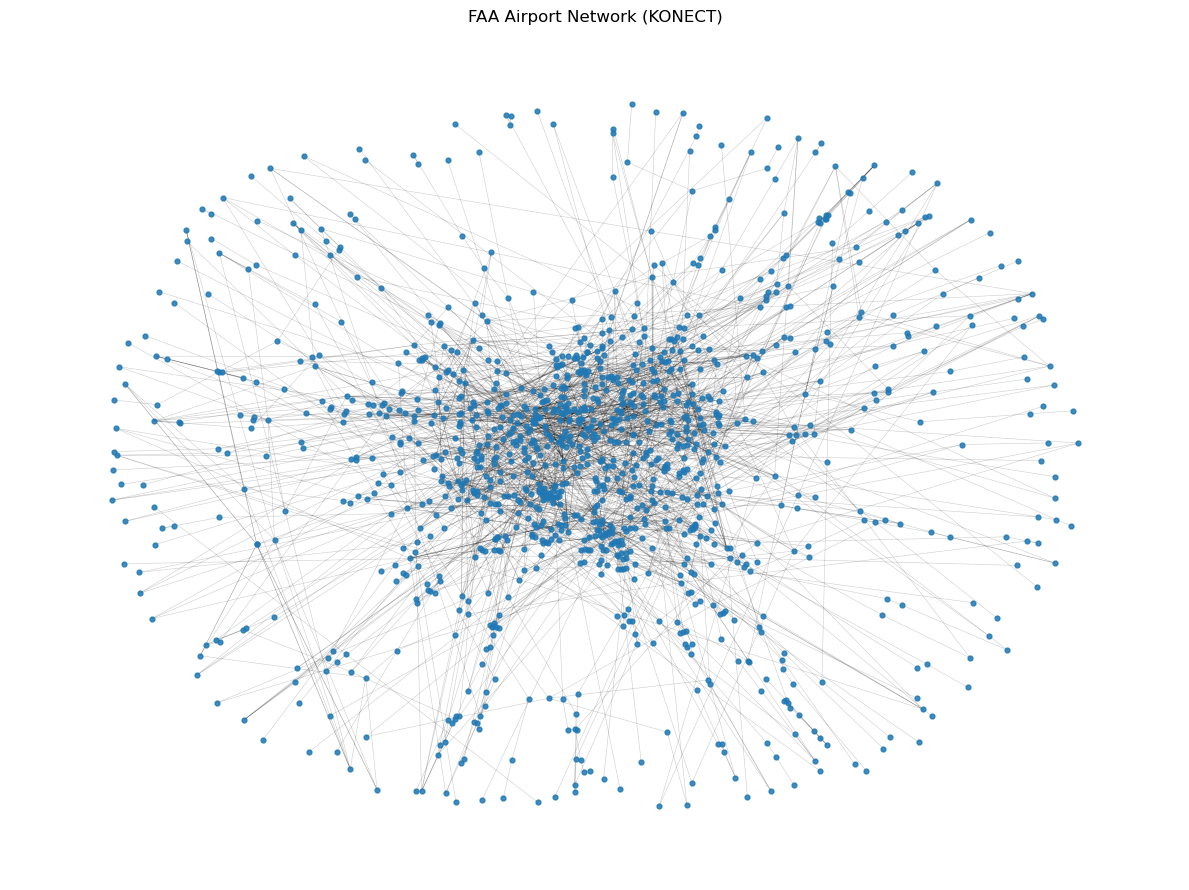

In [9]:
import matplotlib.pyplot as plt

# Plot the directed airport network
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=12, alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.4, arrows=False)
plt.title('FAA Airport Network (KONECT)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# Degree statistics
avg_total_degree = np.mean([d for _, d in G.degree()])
avg_in_degree = np.mean([d for _, d in G.in_degree()])
avg_out_degree = np.mean([d for _, d in G.out_degree()])

print(f"Average total degree: {avg_total_degree:.4f}")
print(f"Average in-degree: {avg_in_degree:.4f}")
print(f"Average out-degree: {avg_out_degree:.4f}")

# Connected components (for directed graphs, weak/strong variants are both useful)
n_weak = nx.number_weakly_connected_components(G)
n_strong = nx.number_strongly_connected_components(G)
largest_weak = max((len(c) for c in nx.weakly_connected_components(G)), default=0)
largest_strong = max((len(c) for c in nx.strongly_connected_components(G)), default=0)

print(f"Weakly connected components: {n_weak}")
print(f"Strongly connected components: {n_strong}")
print(f"Largest weak component size: {largest_weak}")
print(f"Largest strong component size: {largest_strong}")

# Adjacency matrix and eigenvalues
A = nx.to_numpy_array(G, dtype=float)
eigs = np.linalg.eigvals(A)

print(f"Adjacency matrix shape: {A.shape}")
print(f"Eigenvalues computed: {len(eigs)}")
print(f"Spectral radius: {np.max(np.abs(eigs)):.6f}")

# Show the 10 largest eigenvalue magnitudes
largest_abs = np.sort(np.abs(eigs))[::-1][:10]
print("Top 10 |eigenvalues|:", np.round(largest_abs, 6))

Average total degree: 4.2659
Average in-degree: 2.1330
Average out-degree: 2.1330
Weakly connected components: 1
Strongly connected components: 434
Largest weak component size: 1226
Largest strong component size: 792
Adjacency matrix shape: (1226, 1226)
Eigenvalues computed: 1226
Spectral radius: 5.248327
Top 10 |eigenvalues|: [5.248327 4.4618   3.995093 3.405433 3.226906 3.180914 3.119938 2.804953
 2.804953 2.77592 ]
